# The purpose of the script is to conduct the analysis between the chirps data and our USGS sites and ET data

In [1]:
# Import libraries
import os
import requests
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import rasterio
from scipy.stats import spearmanr # Using for Spearman Rank Correlation
import xarray as xr
import glob
from rasterio.mask import mask
from shapely.geometry import Point
from pyproj import Transformer
from shapely.geometry import box


In [2]:
# Read in ET/GW data 1km
et_gw_merged_all_sites = "/capstone/aridgw/outputs//sites_aridity_1km2.csv"
et_gw_merged_all_sites = pd.read_csv(et_gw_merged_all_sites)
et_gw_merged_all_sites

,year_value,site_id,depth_to_gw_ft,depth_to_gw_m,latitude,longitude,data_source,region,pct_cultivated,bbox_side,open_et_version,scaled_annual_et_avg,AI_1km2,Aridity_class
0,2000,KSGS.371852100505801,239.390000,72.966072,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,781.134,0.2871,arid
1,2001,KSGS.371852100505801,241.960000,73.749408,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,859.635,0.2871,arid
2,2002,KSGS.371852100505801,242.780000,73.999344,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,787.151,0.2871,arid
3,2003,KSGS.371852100505801,246.710000,75.197208,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,836.748,0.2871,arid
4,2004,KSGS.371852100505801,247.710000,75.502008,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,666.882,0.2871,arid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,2014,willcox,346.899946,105.735100,32.03619,-109.7540,Jasechko,SoCal_Arizona,63.636364,1,2.0,942.466,0.1646,arid
987,2015,willcox,352.000011,107.289600,32.03619,-109.7540,Jasechko,SoCal_Arizona,16.804408,1,2.0,735.658,0.1646,arid
988,2017,willcox,372.750012,113.614200,32.03619,-109.7540,Jasechko,SoCal_Arizona,22.497704,1,2.0,530.228,0.1646,arid
989,2019,willcox,392.100078,119.512100,32.03619,-109.7540,Jasechko,SoCal_Arizona,19.559229,1,2.0,591.662,0.1646,arid


### Remaking the precip normal to be from 2000-2020 because thats our data extent

In [ ]:
# Takes 23 mins to run
data_dir = "/capstone/aridgw/data/chirps_daily_data/"

# Filter files for 2000-2020 only
files = sorted(glob.glob(data_dir + "*.tif"))
files = [f for f in files if any(str(year) in f for year in range(2000, 2021))]
print(len(files), "files found")

# Read first file to get metadata
with rasterio.open(files[0]) as src:
    meta = src.meta.copy()
    shape = src.shape

# Initialize sum array
precip_sum = np.zeros(shape, dtype=np.float64)

# Read and sum all files
for i, f in enumerate(files):
    with rasterio.open(f) as src:
        precip_sum += src.read(1)
    if i % 100 == 0:
        print(f"Processed {i}/{len(files)}")

# Calculate mean
precip_mean = precip_sum / len(files)

# Write output
meta.update(dtype=rasterio.float32)
with rasterio.open("/capstone/aridgw/data/chirps_daily_precip_normal_2000_2020.tif", 'w', **meta) as dst:
    dst.write(precip_mean.astype(np.float32), 1)

7671 files found
Processed 0/7671
Processed 100/7671
Processed 200/7671
Processed 300/7671
Processed 400/7671
Processed 500/7671
Processed 600/7671
Processed 700/7671
Processed 800/7671
Processed 900/7671
Processed 1000/7671
Processed 1100/7671
Processed 1200/7671
Processed 1300/7671
Processed 1400/7671
Processed 1500/7671
Processed 1600/7671
Processed 1700/7671
Processed 1800/7671
Processed 1900/7671
Processed 2000/7671
Processed 2100/7671
Processed 2200/7671
Processed 2300/7671
Processed 2400/7671
Processed 2500/7671
Processed 2600/7671
Processed 2700/7671
Processed 2800/7671
Processed 2900/7671
Processed 3000/7671
Processed 3100/7671
Processed 3200/7671
Processed 3300/7671
Processed 3400/7671
Processed 3500/7671
Processed 3600/7671
Processed 3700/7671
Processed 3800/7671
Processed 3900/7671
Processed 4000/7671
Processed 4100/7671
Processed 4200/7671
Processed 4300/7671
Processed 4400/7671
Processed 4500/7671
Processed 4600/7671
Processed 4700/7671
Processed 4800/7671
Processed 4900/

## The mean is calculated by averaging all raster pixel values that intersect the buffered region, with each intersecting pixel contributing equally regardless of how much of its area overlaps the buffer.

In [3]:
et_gw_merged_all_sites = et_gw_merged_all_sites.copy()

def extract_precip_with_buffer(lon, lat, src, buffer_km=0.5):

    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    x, y = transformer.transform(lon, lat)

    point = Point(x, y)

    # ✅ REPLACE circular buffer with square
    half_size = buffer_km / 111.32
    geom = box(
        x - half_size, y - half_size,
        x + half_size, y + half_size
    )

    out_image, out_transform = mask(
        src,
        [geom],
        crop=True,
        all_touched=True
    )

    data = out_image[0]

    return data.mean() if data.size > 0 else np.nan

with rasterio.open("/capstone/aridgw/data/chirps_daily_precip_normal_2000_2020.tif") as src:
    precip_values = [
        extract_precip_with_buffer(lon, lat, src, buffer_km=0.5)
        for lon, lat in zip(
            et_gw_merged_all_sites["longitude"],
            et_gw_merged_all_sites["latitude"]
        )
    ]

et_gw_merged_all_sites["chirps_precip_normal"] = precip_values
et_gw_merged_all_sites

,year_value,site_id,depth_to_gw_ft,depth_to_gw_m,latitude,longitude,data_source,region,pct_cultivated,bbox_side,open_et_version,scaled_annual_et_avg,AI_1km2,Aridity_class,chirps_precip_normal
0,2000,KSGS.371852100505801,239.390000,72.966072,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,781.134,0.2871,arid,1.511885
1,2001,KSGS.371852100505801,241.960000,73.749408,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,859.635,0.2871,arid,1.511885
2,2002,KSGS.371852100505801,242.780000,73.999344,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,787.151,0.2871,arid,1.511885
3,2003,KSGS.371852100505801,246.710000,75.197208,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,836.748,0.2871,arid,1.511885
4,2004,KSGS.371852100505801,247.710000,75.502008,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,666.882,0.2871,arid,1.511885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,2014,willcox,346.899946,105.735100,32.03619,-109.7540,Jasechko,SoCal_Arizona,63.636364,1,2.0,942.466,0.1646,arid,0.912725
987,2015,willcox,352.000011,107.289600,32.03619,-109.7540,Jasechko,SoCal_Arizona,16.804408,1,2.0,735.658,0.1646,arid,0.912725
988,2017,willcox,372.750012,113.614200,32.03619,-109.7540,Jasechko,SoCal_Arizona,22.497704,1,2.0,530.228,0.1646,arid,0.912725
989,2019,willcox,392.100078,119.512100,32.03619,-109.7540,Jasechko,SoCal_Arizona,19.559229,1,2.0,591.662,0.1646,arid,0.912725


In [4]:
# Calculate groundwater trend per site
df = et_gw_merged_all_sites.copy()

def calc_trend(group):
    # drop missing values
    g = group.dropna(subset=["year_value", "depth_to_gw_m"])
    if len(g) < 2:
        return np.nan
    
    # slope (m/year)
    slope = np.polyfit(g["year_value"], g["depth_to_gw_m"], 1)[0]
    return slope

gw_trends = df.groupby("site_id").apply(calc_trend).reset_index()
gw_trends.columns = ["site_id", "gw_trend_m_per_yr"]

# Compute ET : Precip ratio per site
climate = df.groupby("site_id").agg(
    region=("region", "first"),
    mean_et=("scaled_annual_et_avg", "mean"),
    mean_precip=("chirps_precip_normal", "mean"),
    AI_1km2=("AI_1km2", "first"),
    Aridity_class=("Aridity_class", "first"),
).reset_index()

# Multiply by 365 to get from mm/day to mm/year
climate["mean_precip"] = climate["mean_precip"] * 365

climate["et_precip_ratio"] = climate["mean_et"] / climate["mean_precip"]

# Merge them
site_summary = gw_trends.merge(climate, on="site_id")
site_summary

/tmp/ipykernel_2590557/2963114397.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gw_trends = df.groupby("site_id").apply(calc_trend).reset_index()


,site_id,gw_trend_m_per_yr,region,mean_et,mean_precip,AI_1km2,Aridity_class,et_precip_ratio
0,KSGS.371852100505801,0.616701,Southern Kansas,797.106238,551.838196,0.2871,arid,1.444456
1,KSGS.372043101363101,0.213301,Southern Kansas,522.713143,514.423035,0.2302,arid,1.016115
2,KSGS.372539100142504,1.047972,Southern Kansas,829.910619,605.144165,0.3153,arid,1.371426
3,KSGS.373331098033301,0.063359,Southern Kansas,860.773810,929.180420,0.4661,arid,0.926380
4,KSGS.373607100565301,0.595615,Southern Kansas,616.277619,523.986206,0.2782,arid,1.176133
5,KSGS.374111099070401,0.176172,Southern Kansas,800.964048,737.784912,0.3797,arid,1.085634
6,KSGS.374125100344101,1.690761,Southern Kansas,795.150381,576.212463,0.3101,arid,1.379960
7,KSGS.374747100552101,1.912739,Southern Kansas,885.796714,526.873352,0.2908,arid,1.681233
8,KSGS.375145100485701,1.217462,Southern Kansas,899.119333,531.417358,0.2917,arid,1.691927
9,KSGS.375454101075401,1.541198,Southern Kansas,999.956667,532.699219,0.2784,arid,1.877151


In [ ]:
# Save site_summary as a csv to outputs folder in server
# site_summary.to_csv("/capstone/aridgw/outputs/site_summary_1km2.csv", index=False)

In [5]:
et_gw_merged_all_sites = et_gw_merged_all_sites.merge(
    site_summary[['site_id', 'mean_et', 'mean_precip', 'et_precip_ratio']],
    on = 'site_id',
    how = 'left'
)

et_gw_merged_all_sites = et_gw_merged_all_sites.drop(columns="chirps_precip_normal")

et_gw_merged_all_sites

,year_value,site_id,depth_to_gw_ft,depth_to_gw_m,latitude,longitude,data_source,region,pct_cultivated,bbox_side,open_et_version,scaled_annual_et_avg,AI_1km2,Aridity_class,mean_et,mean_precip,et_precip_ratio
0,2000,KSGS.371852100505801,239.390000,72.966072,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,781.134,0.2871,arid,797.106238,551.838196,1.444456
1,2001,KSGS.371852100505801,241.960000,73.749408,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,859.635,0.2871,arid,797.106238,551.838196,1.444456
2,2002,KSGS.371852100505801,242.780000,73.999344,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,787.151,0.2871,arid,797.106238,551.838196,1.444456
3,2003,KSGS.371852100505801,246.710000,75.197208,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,836.748,0.2871,arid,797.106238,551.838196,1.444456
4,2004,KSGS.371852100505801,247.710000,75.502008,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,666.882,0.2871,arid,797.106238,551.838196,1.444456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,2014,willcox,346.899946,105.735100,32.03619,-109.7540,Jasechko,SoCal_Arizona,63.636364,1,2.0,942.466,0.1646,arid,817.900583,333.144501,2.455093
987,2015,willcox,352.000011,107.289600,32.03619,-109.7540,Jasechko,SoCal_Arizona,16.804408,1,2.0,735.658,0.1646,arid,817.900583,333.144501,2.455093
988,2017,willcox,372.750012,113.614200,32.03619,-109.7540,Jasechko,SoCal_Arizona,22.497704,1,2.0,530.228,0.1646,arid,817.900583,333.144501,2.455093
989,2019,willcox,392.100078,119.512100,32.03619,-109.7540,Jasechko,SoCal_Arizona,19.559229,1,2.0,591.662,0.1646,arid,817.900583,333.144501,2.455093


In [ ]:
# Save et_gw_merged_all_sites as a csv to outputs folder in server
#et_gw_merged_all_sites.to_csv(
#    "/capstone/aridgw/outputs/et_precipt_ratio_1km2.csv",
#    index = False
#)

In [7]:
# Read in ET/GW data 1km
et_gw_merged_all_sites = "/capstone/aridgw/outputs/et_precipt_ratio_1km2.csv"
et_gw_merged_all_sites = pd.read_csv(et_gw_merged_all_sites)
et_gw_merged_all_sites

,year_value,site_id,depth_to_gw_ft,depth_to_gw_m,latitude,longitude,data_source,region,pct_cultivated,bbox_side,open_et_version,scaled_annual_et_avg,AI_1km2,Aridity_class,mean_et,mean_precip,et_precip_ratio
0,2000,KSGS.371852100505801,239.390000,72.966072,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,781.134,0.2871,arid,797.106238,551.8382,1.444456
1,2001,KSGS.371852100505801,241.960000,73.749408,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,859.635,0.2871,arid,797.106238,551.8382,1.444456
2,2002,KSGS.371852100505801,242.780000,73.999344,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,787.151,0.2871,arid,797.106238,551.8382,1.444456
3,2003,KSGS.371852100505801,246.710000,75.197208,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,836.748,0.2871,arid,797.106238,551.8382,1.444456
4,2004,KSGS.371852100505801,247.710000,75.502008,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,666.882,0.2871,arid,797.106238,551.8382,1.444456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,2014,willcox,346.899946,105.735100,32.03619,-109.7540,Jasechko,SoCal_Arizona,63.636364,1,2.0,942.466,0.1646,arid,817.900583,333.1445,2.455093
987,2015,willcox,352.000011,107.289600,32.03619,-109.7540,Jasechko,SoCal_Arizona,16.804408,1,2.0,735.658,0.1646,arid,817.900583,333.1445,2.455093
988,2017,willcox,372.750012,113.614200,32.03619,-109.7540,Jasechko,SoCal_Arizona,22.497704,1,2.0,530.228,0.1646,arid,817.900583,333.1445,2.455093
989,2019,willcox,392.100078,119.512100,32.03619,-109.7540,Jasechko,SoCal_Arizona,19.559229,1,2.0,591.662,0.1646,arid,817.900583,333.1445,2.455093


# Raw plot:

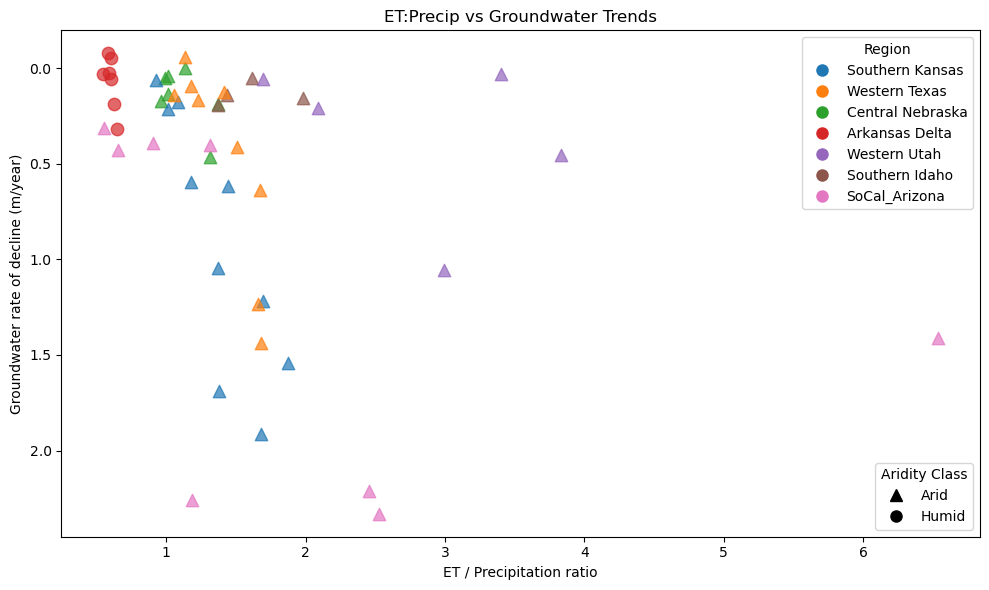

In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(10, 6))

# --- assign consistent colors to regions ---
regions = site_summary["region"].unique()
colors = plt.cm.tab10(range(len(regions)))  # nice distinct palette
color_map = dict(zip(regions, colors))

# --- plot ---
for region, group in site_summary.groupby("region"):

    arid = group[group["Aridity_class"] == "arid"]
    humid = group[group["Aridity_class"] == "humid"]

    # arid = square
    plt.scatter(
        arid["et_precip_ratio"],
        arid["gw_trend_m_per_yr"],
        s=80,
        marker="^",
        color=color_map[region],
        alpha=0.7
    )

    # humid = circle
    plt.scatter(
        humid["et_precip_ratio"],
        humid["gw_trend_m_per_yr"],
        s=80,
        marker="o",
        color=color_map[region],
        alpha=0.7
    )

# --- labels ---
plt.xlabel("ET / Precipitation ratio")
plt.ylabel("Groundwater rate of decline (m/year)")
plt.title("ET:Precip vs Groundwater Trends")
plt.gca().invert_yaxis()

# --- legend 1: region colors ---
region_legend = [
    Line2D([0], [0], marker='o', color=color_map[r], linestyle='None',
           markersize=8, label=r)
    for r in regions
]
legend1 = plt.legend(handles=region_legend, title="Region", loc="upper right")
plt.gca().add_artist(legend1)

# --- legend 2: aridity shapes ---
shape_legend = [
    Line2D([0], [0], marker='^', color='black', linestyle='None',
           markersize=8, label='Arid'),
    Line2D([0], [0], marker='o', color='black', linestyle='None',
           markersize=8, label='Humid')
]

plt.legend(handles=shape_legend, title="Aridity Class", loc="lower right")

plt.tight_layout()
plt.show()

# X-axis on log scale

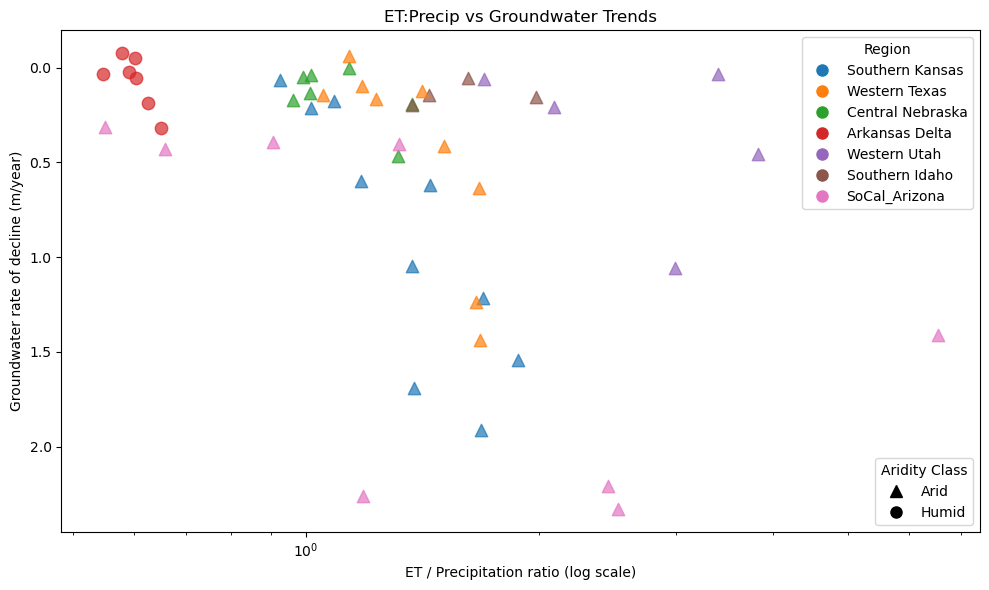

In [9]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

plt.figure(figsize=(10, 6))

# --- consistent region colors ---
regions = site_summary["region"].unique()
colors = plt.cm.tab10(range(len(regions)))
color_map = dict(zip(regions, colors))

# --- plot ---
for region, group in site_summary.groupby("region"):

    arid = group[group["Aridity_class"] == "arid"]
    humid = group[group["Aridity_class"] == "humid"]

    # arid = triangle
    plt.scatter(
        arid["et_precip_ratio"],
        arid["gw_trend_m_per_yr"],
        s=80,
        marker="^",
        color=color_map[region],
        alpha=0.7
    )

    # humid = circle
    plt.scatter(
        humid["et_precip_ratio"],
        humid["gw_trend_m_per_yr"],
        s=80,
        marker="o",
        color=color_map[region],
        alpha=0.7
    )

# --- log scale ---
plt.xscale("log")

# --- labels ---
plt.xlabel("ET / Precipitation ratio (log scale)")
plt.ylabel("Groundwater rate of decline (m/year)")
plt.title("ET:Precip vs Groundwater Trends")

plt.gca().invert_yaxis()

# --- legend 1: region colors ---
region_legend = [
    Line2D([0], [0], marker='o', color=color_map[r], linestyle='None',
           markersize=8, label=r)
    for r in regions
]
legend1 = plt.legend(handles=region_legend, title="Region", loc="upper right")
plt.gca().add_artist(legend1)

# --- legend 2: aridity shapes ---
shape_legend = [
    Line2D([0], [0], marker='^', color='black', linestyle='None',
           markersize=8, label='Arid'),
    Line2D([0], [0], marker='o', color='black', linestyle='None',
           markersize=8, label='Humid')
]

plt.legend(handles=shape_legend, title="Aridity Class", loc="lower right")

plt.tight_layout()
plt.show()

# Y-axis on log scale

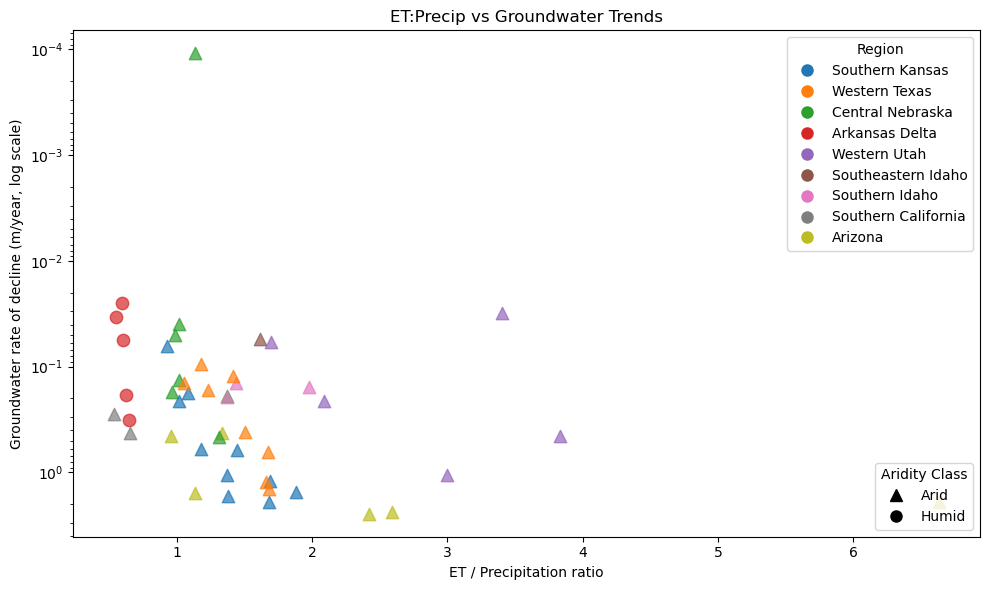

In [28]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(10, 6))

# --- consistent colors for regions ---
regions = site_summary["region"].unique()
colors = plt.cm.tab10(range(len(regions)))
color_map = dict(zip(regions, colors))

# --- plot ---
for region, group in site_summary.groupby("region"):

    arid = group[group["Aridity_class"] == "arid"]
    humid = group[group["Aridity_class"] == "humid"]

    # arid = triangle
    plt.scatter(
        arid["et_precip_ratio"],
        arid["gw_trend_m_per_yr"],
        s=80,
        marker="^",
        color=color_map[region],
        alpha=0.7
    )

    # humid = circle
    plt.scatter(
        humid["et_precip_ratio"],
        humid["gw_trend_m_per_yr"],
        s=80,
        marker="o",
        color=color_map[region],
        alpha=0.7
    )

# --- log scale on Y axis ---
plt.yscale("log")

# --- labels ---
plt.xlabel("ET / Precipitation ratio")
plt.ylabel("Groundwater rate of decline (m/year, log scale)")
plt.title("ET:Precip vs Groundwater Trends")

# keep your inversion
plt.gca().invert_yaxis()

# --- legend 1: region colors ---
region_legend = [
    Line2D([0], [0], marker='o', color=color_map[r], linestyle='None',
           markersize=8, label=r)
    for r in regions
]
legend1 = plt.legend(handles=region_legend, title="Region", loc="upper right")
plt.gca().add_artist(legend1)

# --- legend 2: aridity shapes ---
shape_legend = [
    Line2D([0], [0], marker='^', color='black', linestyle='None',
           markersize=8, label='Arid'),
    Line2D([0], [0], marker='o', color='black', linestyle='None',
           markersize=8, label='Humid')
]

plt.legend(handles=shape_legend, title="Aridity Class", loc="lower right")

plt.tight_layout()
plt.show()

# Y-axis and X-axis on log scale

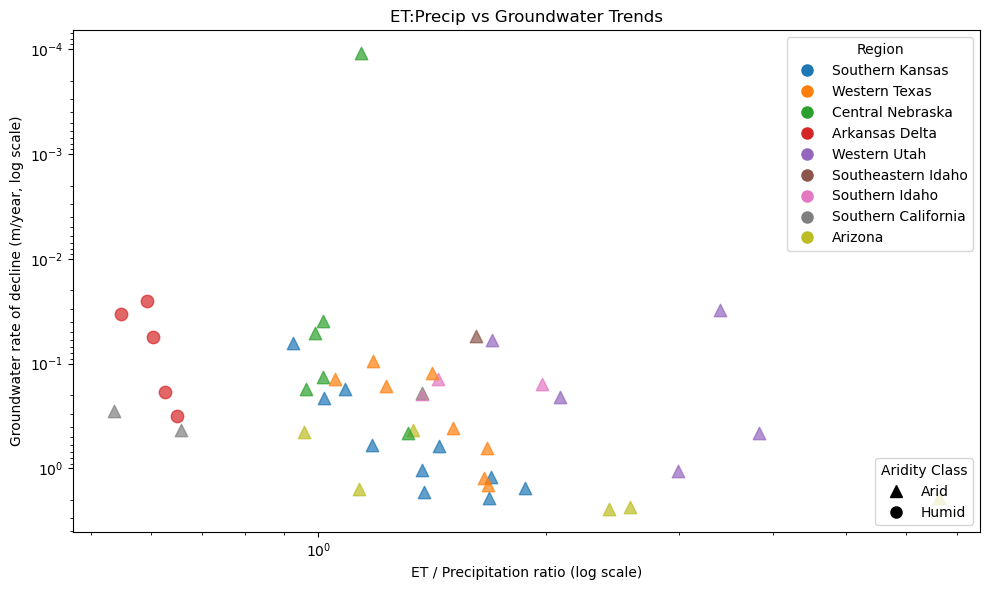

In [29]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(10, 6))

# --- consistent colors for regions ---
regions = site_summary["region"].unique()
colors = plt.cm.tab10(range(len(regions)))
color_map = dict(zip(regions, colors))

# --- plot ---
for region, group in site_summary.groupby("region"):

    arid = group[group["Aridity_class"] == "arid"]
    humid = group[group["Aridity_class"] == "humid"]

    # arid = triangle
    plt.scatter(
        arid["et_precip_ratio"],
        arid["gw_trend_m_per_yr"],
        s=80,
        marker="^",
        color=color_map[region],
        alpha=0.7
    )

    # humid = circle
    plt.scatter(
        humid["et_precip_ratio"],
        humid["gw_trend_m_per_yr"],
        s=80,
        marker="o",
        color=color_map[region],
        alpha=0.7
    )

# --- log scales ---
plt.xscale("log")
plt.yscale("log")

# --- labels ---
plt.xlabel("ET / Precipitation ratio (log scale)")
plt.ylabel("Groundwater rate of decline (m/year, log scale)")
plt.title("ET:Precip vs Groundwater Trends")

plt.gca().invert_yaxis()

# --- legend 1: regions (colors) ---
region_legend = [
    Line2D([0], [0], marker='o', color=color_map[r], linestyle='None',
           markersize=8, label=r)
    for r in regions
]
legend1 = plt.legend(handles=region_legend, title="Region", loc="upper right")
plt.gca().add_artist(legend1)

# --- legend 2: aridity (shapes) ---
shape_legend = [
    Line2D([0], [0], marker='^', color='black', linestyle='None',
           markersize=8, label='Arid'),
    Line2D([0], [0], marker='o', color='black', linestyle='None',
           markersize=8, label='Humid')
]

plt.legend(handles=shape_legend, title="Aridity Class", loc="lower right")

plt.tight_layout()
plt.show()